student_number = "401102791"   
Name = "Narges"             
Last_Name = "Vali"       

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.cm as cm
import pandas as pd
from imblearn.over_sampling import SMOTE

# part 1: kNN classifier
## Question 1(20pts)

In this section, we will implement a kNN classifier from scratch.

In [38]:
# TODO 1.1: Implement the KNNClassifier class from scratch.

class KNNClassifier:
    def __init__(self, k=3, distance_metric="euclidean", p=3):
        self.k = k
        self.distance_metric = distance_metric
        self.p = p
        self.X_train = None
        self.y_train = None

    def fit(self, X_train, y_train):
        self.X_train = np.array(X_train)
        self.y_train = np.array(y_train)

    def _distance(self, x1, x2):
        if self.distance_metric == "euclidean":
            return np.sqrt(np.sum((x1 - x2) ** 2))

        elif self.distance_metric == "manhattan":
            return np.sum(np.abs(x1 - x2))

        elif self.distance_metric == "minkowski":
            return np.sum(np.abs(x1 - x2) ** self.p) ** (1 / self.p)

        else:
            raise ValueError("Unsupported distance metric")

    def _predict_one(self, x):
        distances = []

        for i in range(len(self.X_train)):
            dist = self._distance(x, self.X_train[i])
            distances.append((dist, self.y_train[i]))

        distances.sort(key=lambda item: item[0])

        k_nearest = distances[:self.k]
        k_nearest_labels = [label for _, label in k_nearest]

        labels, counts = np.unique(k_nearest_labels, return_counts=True)
        predicted_label = labels[np.argmax(counts)]

        return predicted_label

    def predict(self, X_test):
        X_test = np.array(X_test)
        predictions = [self._predict_one(x) for x in X_test]
        return np.array(predictions)


Using the kNN classifier defined, we can apply different distance measures. Let us generate some random sample points:

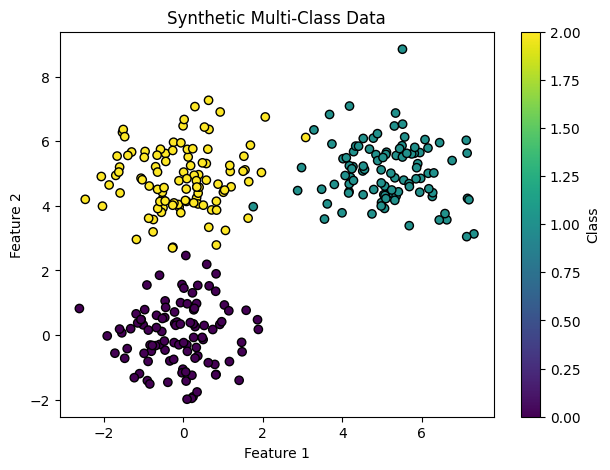

In [33]:
# TODO 1.2: Generate and visualize synthetic multi-class data.

np.random.seed(42)

n_samples = 100

class_0 = np.random.randn(n_samples, 2) + np.array([0, 0])
class_1 = np.random.randn(n_samples, 2) + np.array([5, 5])
class_2 = np.random.randn(n_samples, 2) + np.array([0, 5])

X = np.vstack((class_0, class_1, class_2))

y = np.array(
    [0] * n_samples +
    [1] * n_samples +
    [2] * n_samples
)

plt.figure(figsize=(7, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="viridis", edgecolor="k")
plt.title("Synthetic Multi-Class Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.colorbar(label="Class")
plt.show()


Find the training and test samples below.

In [34]:
# TODO 1.3: Split the synthetic data into training and test sets.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (240, 2)
X_test shape: (60, 2)
y_train shape: (240,)
y_test shape: (60,)


## Question 2(20pts)
Define three distance methods:

<span style="color:pink">Explain each one briefly.</span>

In [35]:
# TODO 2.1: Define Euclidean, Manhattan, and Minkowski distance functions.

def euclidean_distance(x1, x2):
    """
    Euclidean distance:
    Straight-line distance between two points.
    """
    return np.sqrt(np.sum((np.array(x1) - np.array(x2)) ** 2))


def manhattan_distance(x1, x2):
    """
    Manhattan distance:
    Sum of absolute differences along each feature.
    """
    return np.sum(np.abs(np.array(x1) - np.array(x2)))


def minkowski_distance(x1, x2, p=3):
    """
    Minkowski distance:
    Generalized distance measure.
    For p=1 -> Manhattan
    For p=2 -> Euclidean
    """
    return np.sum(np.abs(np.array(x1) - np.array(x2)) ** p) ** (1 / p)


Let's visualize:

In [36]:
# TODO 2.2: Implement a function to plot kNN decision boundaries.

def plot_decision_boundary(model, X, y, title="kNN Decision Boundary"):
    h = 0.05  # step size in the mesh

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid_points)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap="viridis")
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", cmap="viridis")
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()


Accuracy: 1.0


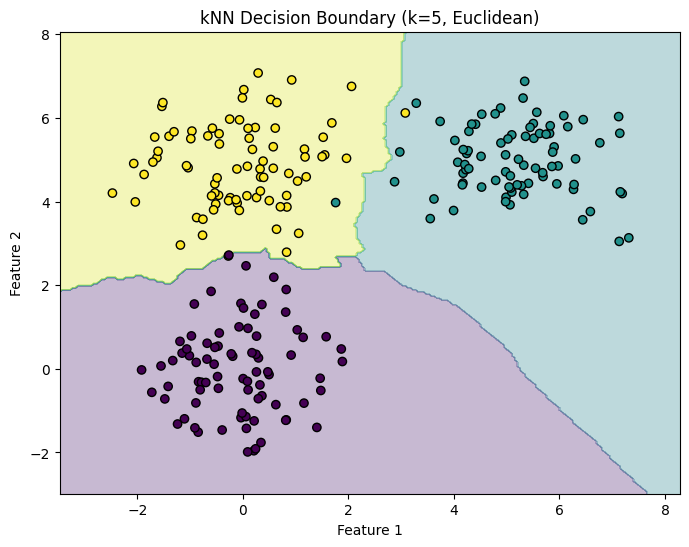

In [37]:
# TODO 2.3: Fit kNN with a chosen k and visualize the decision boundary.

knn_q2 = KNNClassifier(k=5, distance_metric="euclidean")
knn_q2.fit(X_train, y_train)

y_pred_q2 = knn_q2.predict(X_test)
acc_q2 = accuracy_score(y_test, y_pred_q2)

print("Accuracy:", acc_q2)

plot_decision_boundary(knn_q2, X_train, y_train, title="kNN Decision Boundary (k=5, Euclidean)")


## Question 3(20pts)
Plot the accuracy based on k values.
* Perform this for all the distance functions you defined earlier (Euclidean, Manhattan, and Minkowski).

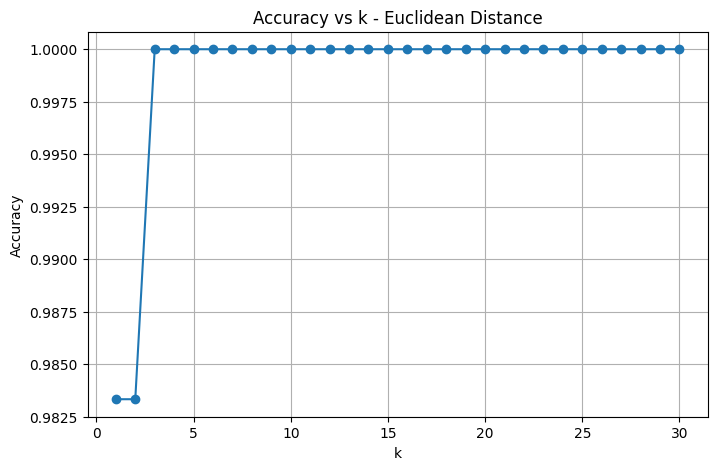

Best Euclidean Accuracy: 1.0
Best k for Euclidean: 3


In [39]:
# TODO 3.1: Plot accuracy versus k for Euclidean distance.

k_values = range(1, 31)
euclidean_accuracies = []

for k in k_values:
    knn = KNNClassifier(k=k, distance_metric="euclidean")
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    euclidean_accuracies.append(acc)

plt.figure(figsize=(8, 5))
plt.plot(k_values, euclidean_accuracies, marker="o")
plt.title("Accuracy vs k - Euclidean Distance")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

print("Best Euclidean Accuracy:", max(euclidean_accuracies))
print("Best k for Euclidean:", k_values[np.argmax(euclidean_accuracies)])


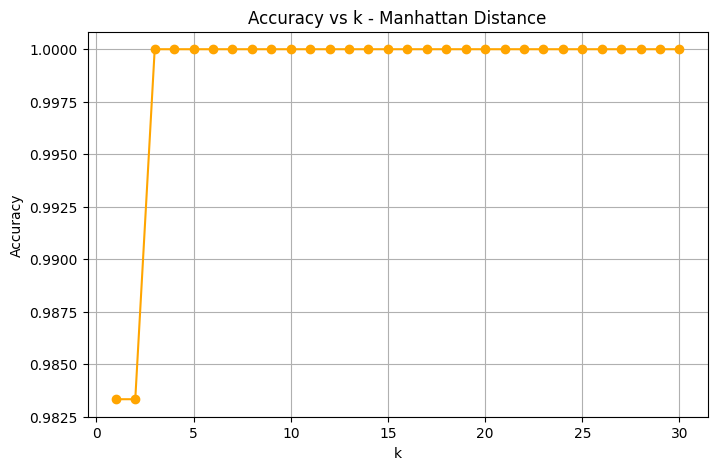

Best Manhattan Accuracy: 1.0
Best k for Manhattan: 3


In [40]:
# TODO 3.2: Plot accuracy versus k for Manhattan distance.

manhattan_accuracies = []

for k in k_values:
    knn = KNNClassifier(k=k, distance_metric="manhattan")
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    manhattan_accuracies.append(acc)

plt.figure(figsize=(8, 5))
plt.plot(k_values, manhattan_accuracies, marker="o", color="orange")
plt.title("Accuracy vs k - Manhattan Distance")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

print("Best Manhattan Accuracy:", max(manhattan_accuracies))
print("Best k for Manhattan:", k_values[np.argmax(manhattan_accuracies)])


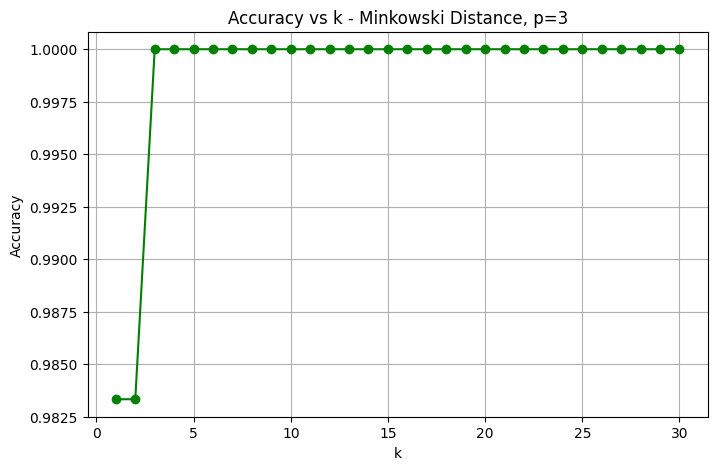

Best Minkowski Accuracy: 1.0
Best k for Minkowski: 3


In [41]:
# TODO 3.3: Plot accuracy versus k for Minkowski distance.

minkowski_accuracies = []

for k in k_values:
    knn = KNNClassifier(k=k, distance_metric="minkowski", p=3)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    minkowski_accuracies.append(acc)

plt.figure(figsize=(8, 5))
plt.plot(k_values, minkowski_accuracies, marker="o", color="green")
plt.title("Accuracy vs k - Minkowski Distance, p=3")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

print("Best Minkowski Accuracy:", max(minkowski_accuracies))
print("Best k for Minkowski:", k_values[np.argmax(minkowski_accuracies)])


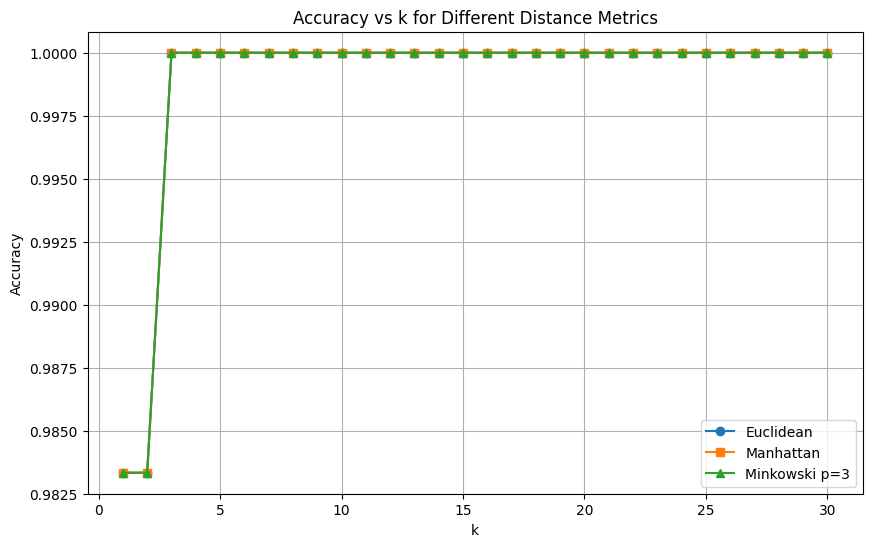

Euclidean best accuracy: 1.0 at k = 3
Manhattan best accuracy: 1.0 at k = 3
Minkowski best accuracy: 1.0 at k = 3


In [42]:
# TODO 3.4: Compare decision boundaries and accuracy curves for all distance functions.

plt.figure(figsize=(10, 6))

plt.plot(k_values, euclidean_accuracies, marker="o", label="Euclidean")
plt.plot(k_values, manhattan_accuracies, marker="s", label="Manhattan")
plt.plot(k_values, minkowski_accuracies, marker="^", label="Minkowski p=3")

plt.title("Accuracy vs k for Different Distance Metrics")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

print("Euclidean best accuracy:", max(euclidean_accuracies), "at k =", k_values[np.argmax(euclidean_accuracies)])
print("Manhattan best accuracy:", max(manhattan_accuracies), "at k =", k_values[np.argmax(manhattan_accuracies)])
print("Minkowski best accuracy:", max(minkowski_accuracies), "at k =", k_values[np.argmax(minkowski_accuracies)])


# part 2: The Loan Dataset
## Question 4(20pts)

1. Seperate dependent features (Loan_Status) from independent features.

In [43]:
# TODO 4.1: Load the Loan dataset and inspect its first rows.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
loan_df = pd.read_csv("loan.csv")

# Show first rows
loan_df.head()


,Unnamed: 0,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,0,1,0,0,1,0,5849,0.0,146.412162,360.0,1,1,1
1,1,1,1,1,1,0,4583,1508.0,128.000000,360.0,1,0,0
2,2,1,1,0,1,1,3000,0.0,66.000000,360.0,1,1,1
3,3,1,1,0,0,0,2583,2358.0,120.000000,360.0,1,1,1
4,4,1,0,0,1,0,6000,0.0,141.000000,360.0,1,1,1


2. Seperate dependent features (Loan_Status) from independent features.

In [49]:
# TODO 4.2: Print the categories or unique values for each feature.

for column in loan_df.columns:
    print(f"\nColumn: {column}")
    print("Number of unique values:", loan_df[column].nunique())
    print("Unique values:")
    print(loan_df[column].unique())




Column: Unnamed: 0
Number of unique values: 524
Unique values:
[  0   1   2   3   4   5   6   7   8  10  11  12  13  15  16  17  18  19
  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37
  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54  55
  56  57  58  59  60  61  63  64  65  67  69  70  71  72  73  74  76  77
  78  79  80  81  82  83  84  85  86  87  88  89  90  92  93  95  96  97
  99 101 102 103 104 105 106 107 108 110 111 112 113 114 116 117 118 119
 120 121 122 123 124 125 127 129 131 132 134 135 136 137 138 139 140 141
 143 145 146 147 148 149 150 151 152 153 154 156 157 158 159 160 161 162
 163 165 166 167 169 170 173 174 175 176 178 180 181 184 186 187 188 190
 191 192 193 194 195 196 197 198 199 200 201 203 204 205 206 207 208 209
 210 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225 226 227
 229 230 232 233 234 235 236 237 238 239 240 243 244 246 249 250 251 252
 254 255 256 257 258 259 260 261 263 264 265 266 267 268 269

3. Normalize the data to the range of independent variables or features of data.

In [50]:
# TODO 4.3: Normalize the independent numerical features.

df = loan_df.copy()

# Drop Loan_ID if it exists
if "Loan_ID" in df.columns:
    df = df.drop("Loan_ID", axis=1)

# Fill missing values
for column in df.columns:
    if df[column].dtype == "object":
        df[column] = df[column].fillna(df[column].mode()[0])
    else:
        df[column] = df[column].fillna(df[column].median())

# Separate dependent and independent variables
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

print("X shape:", X.shape)
print("y shape:", y.shape)


scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

display(X_scaled.head())



X shape: (524, 12)
y shape: (524,)


,Unnamed: 0,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,0.000000,1.0,0.0,0.000000,1.0,0.0,0.316347,0.000000,0.321808,1.0,1.0,0.5
1,0.001631,1.0,1.0,0.333333,1.0,0.0,0.246073,0.167929,0.278689,1.0,1.0,0.0
2,0.003263,1.0,1.0,0.000000,1.0,1.0,0.158201,0.000000,0.133489,1.0,1.0,0.5
3,0.004894,1.0,1.0,0.000000,0.0,0.0,0.135054,0.262584,0.259953,1.0,1.0,0.5
4,0.006525,1.0,0.0,0.000000,1.0,0.0,0.324729,0.000000,0.309133,1.0,1.0,0.5


4. Split the data into 80% train and 20% test.

In [51]:
# TODO 4.4: Split the Loan dataset into 80% train and 20% test.

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (419, 12)
X_test shape: (105, 12)
y_train shape: (419,)
y_test shape: (105,)


# part 3: Classification

## Question 5(30pts)
### Classification with implemented KNN
Here, you should use your implemented kNN method to classify the dataset. You can choose any distance function and any k value that you prefer.

Plot the accuracy based on k.

Custom KNN accuracies: [0.7142857142857143, 0.6666666666666666, 0.7904761904761904, 0.7904761904761904, 0.8380952380952381, 0.8285714285714286, 0.8285714285714286, 0.8285714285714286, 0.8285714285714286, 0.8285714285714286, 0.8285714285714286, 0.8285714285714286, 0.8285714285714286, 0.8380952380952381, 0.8380952380952381, 0.8285714285714286, 0.8285714285714286, 0.8285714285714286, 0.8285714285714286, 0.8285714285714286]
Best k (custom): 5
Best accuracy (custom): 0.8380952380952381


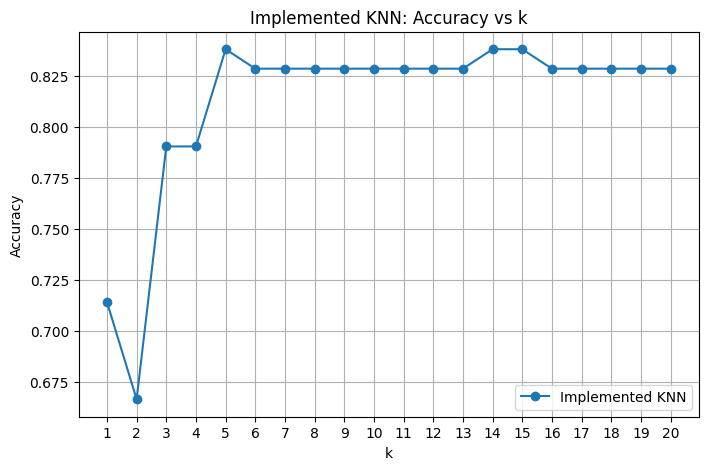

In [52]:
# TODO 5.1: Classify the Loan dataset using your implemented KNN and plot accuracy versus k.

from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

k_values = list(range(1, 21))
custom_accuracies = []

for k in k_values:
    knn_custom = KNNClassifier(k=k, distance_metric='euclidean')
    knn_custom.fit(X_train.values, y_train.values if hasattr(y_train, "values") else y_train)
    y_pred = knn_custom.predict(X_test.values)
    acc = accuracy_score(y_test, y_pred)
    custom_accuracies.append(acc)

best_k_custom = k_values[custom_accuracies.index(max(custom_accuracies))]
best_acc_custom = max(custom_accuracies)

print("Custom KNN accuracies:", custom_accuracies)
print("Best k (custom):", best_k_custom)
print("Best accuracy (custom):", best_acc_custom)

plt.figure(figsize=(8, 5))
plt.plot(k_values, custom_accuracies, marker='o', label='Implemented KNN')
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Implemented KNN: Accuracy vs k")
plt.xticks(k_values)
plt.grid(True)
plt.legend()
plt.show()


Now, use the built-in kNN method in sklearn and plot the accuracy based on k.

Sklearn KNN accuracies: [0.7142857142857143, 0.6666666666666666, 0.7904761904761904, 0.7904761904761904, 0.8380952380952381, 0.8285714285714286, 0.8285714285714286, 0.8285714285714286, 0.8285714285714286, 0.8285714285714286, 0.8285714285714286, 0.8285714285714286, 0.8285714285714286, 0.8380952380952381, 0.8380952380952381, 0.8285714285714286, 0.8285714285714286, 0.8285714285714286, 0.8285714285714286, 0.8285714285714286]
Best k (sklearn): 5
Best accuracy (sklearn): 0.8380952380952381


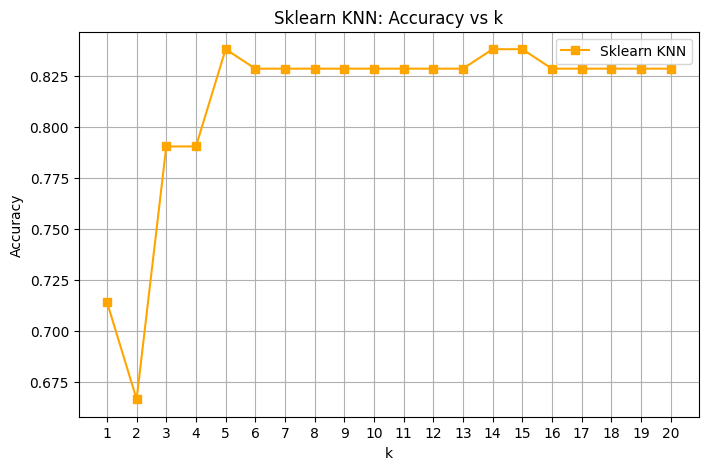

In [53]:
# TODO 5.2: Use sklearn KNeighborsClassifier and plot accuracy versus k.

from sklearn.neighbors import KNeighborsClassifier

sklearn_accuracies = []

for k in k_values:
    knn_sklearn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn_sklearn.fit(X_train, y_train)
    y_pred = knn_sklearn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    sklearn_accuracies.append(acc)

best_k_sklearn = k_values[sklearn_accuracies.index(max(sklearn_accuracies))]
best_acc_sklearn = max(sklearn_accuracies)

print("Sklearn KNN accuracies:", sklearn_accuracies)
print("Best k (sklearn):", best_k_sklearn)
print("Best accuracy (sklearn):", best_acc_sklearn)

plt.figure(figsize=(8, 5))
plt.plot(k_values, sklearn_accuracies, marker='s', color='orange', label='Sklearn KNN')
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Sklearn KNN: Accuracy vs k")
plt.xticks(k_values)
plt.grid(True)
plt.legend()
plt.show()


Now, use the best k value and find the evaluation metrics. Plot the confusion matrix.

Best k: 5
Accuracy: 0.8380952380952381

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.55      0.67        31
           1       0.84      0.96      0.89        74

    accuracy                           0.84       105
   macro avg       0.84      0.75      0.78       105
weighted avg       0.84      0.84      0.83       105



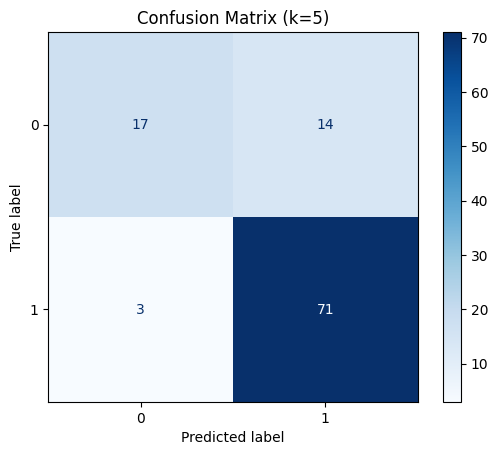

In [54]:
# TODO 5.3: Use the best k, compute evaluation metrics, and plot the confusion matrix.

from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

best_knn = KNeighborsClassifier(n_neighbors=best_k_sklearn, metric='euclidean')
best_knn.fit(X_train, y_train)

y_pred_best = best_knn.predict(X_test)

acc_best = accuracy_score(y_test, y_pred_best)
cm = confusion_matrix(y_test, y_pred_best)
report = classification_report(y_test, y_pred_best)

print("Best k:", best_k_sklearn)
print("Accuracy:", acc_best)
print("\nClassification Report:\n")
print(report)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title(f"Confusion Matrix (k={best_k_sklearn})")
plt.show()


Plot the ROC and PRC curve.

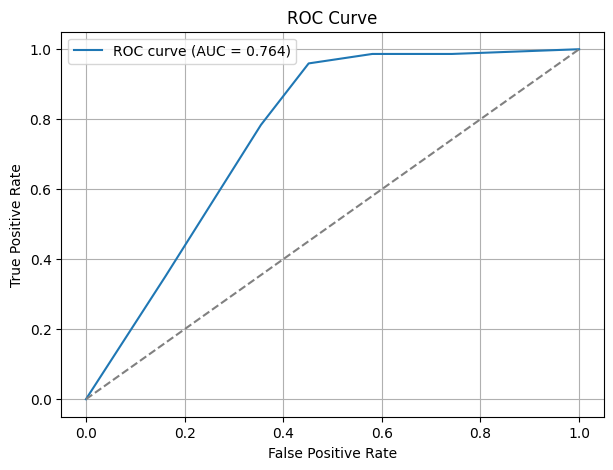

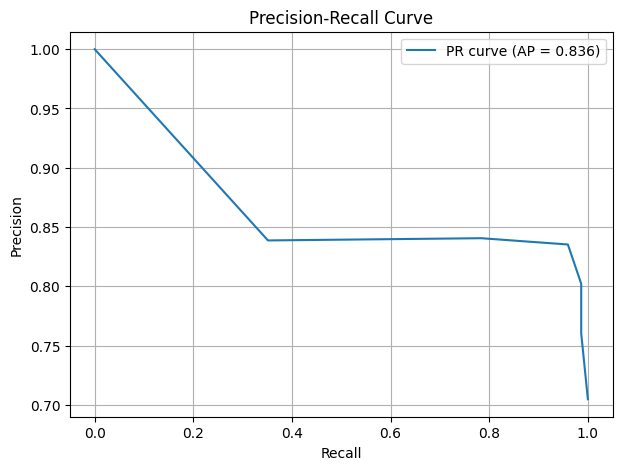

In [55]:
# TODO 5.4: Plot ROC and Precision-Recall curves.

from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Probability estimates for the positive class
y_score = best_knn.predict_proba(X_test)[:, 1]

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_score)
ap_score = average_precision_score(y_test, y_score)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f'PR curve (AP = {ap_score:.3f})')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()



* <span style="color:pink">Compare your implemented kNN method with the built-in one from sklearn.</span>
* <span style="color:pink">Explain the difference of ROC and PRC curve.</span>

## Question 6(10pts)
In previous section, it can be seen that the number between approved and rejected loan is **imbalanced**. In this section, oversampling technique will be used to avoid overfitting.

* You can use 'SMOTE' Technique. 
* <span style="color:pink">Explain the technique that you've used for oversmapling.</span>

Class distribution before SMOTE:
Loan_Status
1    295
0    124
Name: count, dtype: int64

Class distribution after SMOTE:
Loan_Status
1    295
0    295
Name: count, dtype: int64

Evaluation after SMOTE:
Accuracy: 0.7428571428571429
Precision: 0.8507462686567164
Recall: 0.7702702702702703
F1-score: 0.8085106382978723

Classification Report after SMOTE:

              precision    recall  f1-score   support

           0       0.55      0.68      0.61        31
           1       0.85      0.77      0.81        74

    accuracy                           0.74       105
   macro avg       0.70      0.72      0.71       105
weighted avg       0.76      0.74      0.75       105



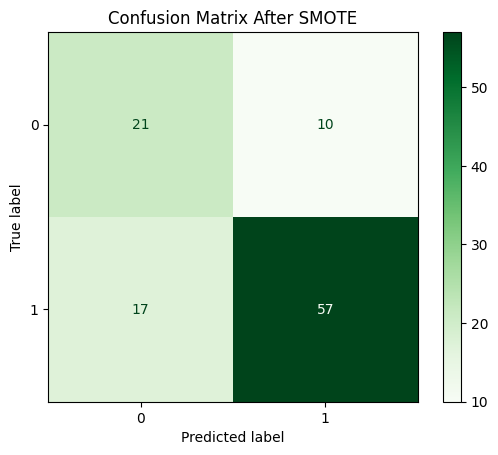

In [56]:
# TODO 6.1: Apply an oversampling method such as SMOTE and evaluate the model.

from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)
import matplotlib.pyplot as plt
import pandas as pd

# 1) Check class distribution before SMOTE
print("Class distribution before SMOTE:")
print(pd.Series(y_train).value_counts())

# 2) Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# 3) Check class distribution after SMOTE
print("\nClass distribution after SMOTE:")
print(pd.Series(y_train_smote).value_counts())

# 4) Train KNN using the best k from previous section
knn_smote = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_smote.fit(X_train_smote, y_train_smote)

# 5) Predict on original test set
y_pred_smote = knn_smote.predict(X_test)

# 6) Evaluation
acc_smote = accuracy_score(y_test, y_pred_smote)
precision_smote = precision_score(y_test, y_pred_smote)
recall_smote = recall_score(y_test, y_pred_smote)
f1_smote = f1_score(y_test, y_pred_smote)

print("\nEvaluation after SMOTE:")
print("Accuracy:", acc_smote)
print("Precision:", precision_smote)
print("Recall:", recall_smote)
print("F1-score:", f1_smote)

print("\nClassification Report after SMOTE:\n")
print(classification_report(y_test, y_pred_smote))

# 7) Confusion Matrix
cm_smote = confusion_matrix(y_test, y_pred_smote)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_smote)
disp.plot(cmap='Greens')
plt.title("Confusion Matrix After SMOTE")
plt.show()


## Question 7(bonus)(10pts)
Now, use the built-in kNN method in sklearn and plot the accuracy based on k. Then, use the best k value. PLot the ROC and PRC curve.

Best k after SMOTE: 13
Best accuracy after SMOTE: 0.7904761904761904


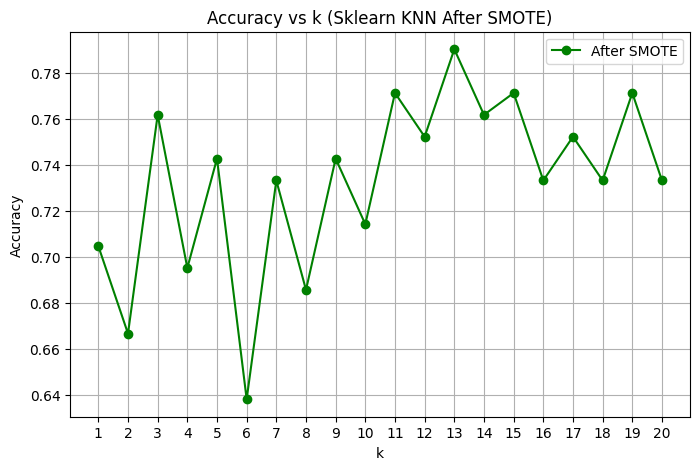

ROC AUC after SMOTE: 0.7554489973844811


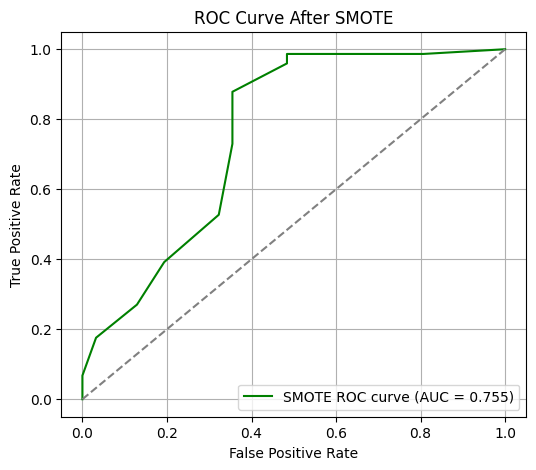

Average Precision after SMOTE: 0.8490248671662708


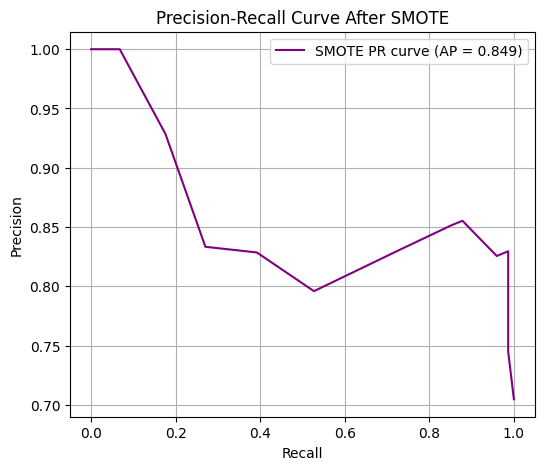

In [58]:
# TODO 7.1: Train sklearn KNN after oversampling, choose the best k, and plot ROC/PRC curves.

import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)


# Find best k after SMOTE

k_values = range(1, 21)
acc_smote_list = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_train_smote, y_train_smote)
    y_pred = knn.predict(X_test)
    acc_smote_list.append(accuracy_score(y_test, y_pred))

best_k_smote = list(k_values)[np.argmax(acc_smote_list)]
best_acc_smote = max(acc_smote_list)

print("Best k after SMOTE:", best_k_smote)
print("Best accuracy after SMOTE:", best_acc_smote)

# Plot accuracy vs k
plt.figure(figsize=(8, 5))
plt.plot(k_values, acc_smote_list, marker='o', color='green', label='After SMOTE')
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Accuracy vs k (Sklearn KNN After SMOTE)")
plt.xticks(list(k_values))
plt.grid(True)
plt.legend()
plt.show()


# Train final model with best k

best_knn_smote = KNeighborsClassifier(n_neighbors=best_k_smote, metric='euclidean')
best_knn_smote.fit(X_train_smote, y_train_smote)

# Predictions and probabilities
y_pred_smote = best_knn_smote.predict(X_test)
y_proba_smote = best_knn_smote.predict_proba(X_test)[:, 1]


# ROC Curve after SMOTE

fpr_smote, tpr_smote, _ = roc_curve(y_test, y_proba_smote)
roc_auc_smote = auc(fpr_smote, tpr_smote)

print("ROC AUC after SMOTE:", roc_auc_smote)

plt.figure(figsize=(6, 5))
plt.plot(fpr_smote, tpr_smote, label=f'SMOTE ROC curve (AUC = {roc_auc_smote:.3f})', color='green')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve After SMOTE")
plt.legend()
plt.grid(True)
plt.show()


# Precision-Recall Curve after SMOTE

precision_smote, recall_smote, _ = precision_recall_curve(y_test, y_proba_smote)
ap_smote = average_precision_score(y_test, y_proba_smote)

print("Average Precision after SMOTE:", ap_smote)

plt.figure(figsize=(6, 5))
plt.plot(recall_smote, precision_smote, label=f'SMOTE PR curve (AP = {ap_smote:.3f})', color='purple')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve After SMOTE")
plt.legend()
plt.grid(True)
plt.show()


* <span style="color:pink">Compare the ROC and PRC of curve of the model befor and after oversampling.</span>